In [17]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import wilcoxon
import itertools
import lists_sessions
# Set style
sns.set_style("whitegrid")
plt.rcParams.update({'font.size': 12})

In [18]:
# Load Data
results_path = os.path.join("spikes", "all_networks_metrics.csv")

if os.path.exists(results_path):
    df = pd.read_csv(results_path)
    print(f"Loaded {len(df)} rows from {results_path}")
    
    # Preprocessing
    # Rename ADAPT to Adapt for consistency
    if "ADAPT" in df.columns:
        df.rename(columns={"ADAPT": "Adapt"}, inplace=True)
        
    print("Columns:", df.columns.tolist())
    print("Adapt levels:", sorted(df["Adapt"].unique()))
    
    display(df.head())
else:
    print(f"File not found: {results_path}. Please run process_live_spikes.py first.")

Loaded 288 rows from spikes\all_networks_metrics.csv
Columns: ['Session', 'Channel', 'Network', 'Adapt', 'TP', 'FP', 'FN', 'Precision', 'Recall', 'F1', 'Mean_Latency', 'Num_Spikes', 'Num_Ripples']
Adapt levels: [0, 2, 20, 120]


,Session,Channel,Network,Adapt,TP,FP,FN,Precision,Recall,F1,Mean_Latency,Num_Spikes,Num_Ripples
0,2025-09-24_10-24-40,30,adapt20_3b,120,71,83,21,0.461039,0.771739,0.577236,24.268545,975,92
1,2025-09-23_15-50-26,28,adapt20_3b,120,133,114,6,0.538462,0.956835,0.689119,22.560652,2307,139
2,2025-09-22_17-55-26,26,adapt20_3b,120,174,170,11,0.505814,0.940541,0.657845,20.160536,3746,185
3,2025-09-25_16-41-14,21,adapt20_3b,120,127,185,17,0.407051,0.881944,0.557018,24.292126,2903,144
4,2025-09-24_14-22-55,25,adapt20_3b,120,264,179,0,0.595937,1.000000,0.746818,8.701515,11176,264


In [19]:
df.loc[(df["Network"] =="updnb4ds_100_7") &  (df["Session"] == "2025-09-25_16-41-14") & (df["Adapt"]==0)]

,Session,Channel,Network,Adapt,TP,FP,FN,Precision,Recall,F1,Mean_Latency,Num_Spikes,Num_Ripples
284,2025-09-25_16-41-14,21,updnb4ds_100_7,0,106,83,38,0.560847,0.736111,0.636637,29.144025,2125,144


In [20]:
hfo_sessions = lists_sessions.HFO_sessions
ripple_sessions = lists_sessions.Ripple_sessions
df = df[~df["Session"].isin(hfo_sessions)]
# df=df[~df["Session"].isin(ripple_sessions)]

In [22]:
# Print summary
print("\n--- Summary by Network ---")
summary = df.groupby("Network")[["F1", "Precision", "Recall", "TP", "FP", "FN"]].mean().round(3)
print(summary)


--- Summary by Network ---
                            F1  Precision  Recall       TP       FP      FN
Network                                                                    
adapt20_3b               0.616      0.479   0.870  124.250  133.750  15.750
dsb4updn_median_200_11b  0.657      0.552   0.821  117.812   95.188  22.188
dsb4updn_median_200_11f  0.668      0.595   0.768  110.312   73.875  29.688
dsb4updn_median_200_12b  0.635      0.742   0.564   82.562   27.875  57.438
dsb4updn_median_200_13f  0.654      0.567   0.778  111.812   83.438  28.188
dsb4updn_median_200_14b  0.637      0.525   0.819  116.875  105.750  23.125
dsb4updn_median_200_15f  0.639      0.524   0.824  118.000  105.688  22.000
dsb4updn_median_200_16b  0.644      0.522   0.846  121.375  110.375  18.625
dsb4updn_median_200_9f   0.634      0.710   0.581   84.875   33.562  55.125
updnb4ds_100_13b         0.673      0.646   0.713  103.250   55.438  36.750
updnb4ds_100_13f         0.674      0.653   0.707  102.562  

In [23]:
print(summary.loc[summary["F1"].idxmax()])

F1             0.674
Precision      0.653
Recall         0.707
TP           102.562
FP            53.500
FN            37.438
Name: updnb4ds_100_13f, dtype: float64


In [24]:
# Print summary
print("\n--- Summary by Adapt ---")
summary = df.groupby("Adapt")[["F1", "Precision", "Recall", "TP", "FP", "FN"]].mean().round(3)
summary = summary.reindex([0, 120, 20, 2])
print(summary)


--- Summary by Adapt ---
          F1  Precision  Recall       TP      FP      FN
Adapt                                                   
0      0.652      0.584   0.771  110.812  83.979  29.188
120    0.652      0.590   0.767  110.521  82.125  29.479
20     0.652      0.590   0.759  109.083  79.625  30.917
2      0.645      0.614   0.713  103.208  68.292  36.792


In [25]:
def barplot_annotate_brackets(num1, num2, data, center, height, ax, yerr=None, dh=.05, barh=.05, fs=None, maxasterix=None):
    """ 
    Annotate barplot with p-values. 
    Adapted from the provided script.
    """
    if type(data) is str:
        text = data
    else:
        if data > 0.05:
          return
        text = ''
        p = .05
        while data < p:
            text += '*'
            p /= 10.
            if maxasterix and len(text) == maxasterix:
                break
        if len(text) == 0:
            text = 'n. s.'

    lx, ly = center[num1], height[num1]
    rx, ry = center[num2], height[num2]

    if yerr:
        ly += yerr[num1]
        ry += yerr[num2]

    ax_y0, ax_y1 = plt.gca().get_ylim()
    dh *= (ax_y1 - ax_y0)
    barh *= (ax_y1 - ax_y0)

    y = max(ly, ry) + dh

    barx = [lx, lx, rx, rx]
    bary = [y, y+barh, y+barh, y]
    mid = ((lx+rx)/2, y+barh)

    ax.plot(barx, bary, c='black')

    kwargs = dict(ha='center', va='bottom')
    if fs is not None:
        kwargs['fontsize'] = fs

    ax.text(*mid, text, **kwargs)

N=48 matched samples for statistics.


C:\Users\NCN\AppData\Local\Temp\ipykernel_18860\1820129339.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Adapt", y=metric, data=plot_df, ax=ax, palette="viridis", width=0.5, showfliers=False, order=adapt_values)


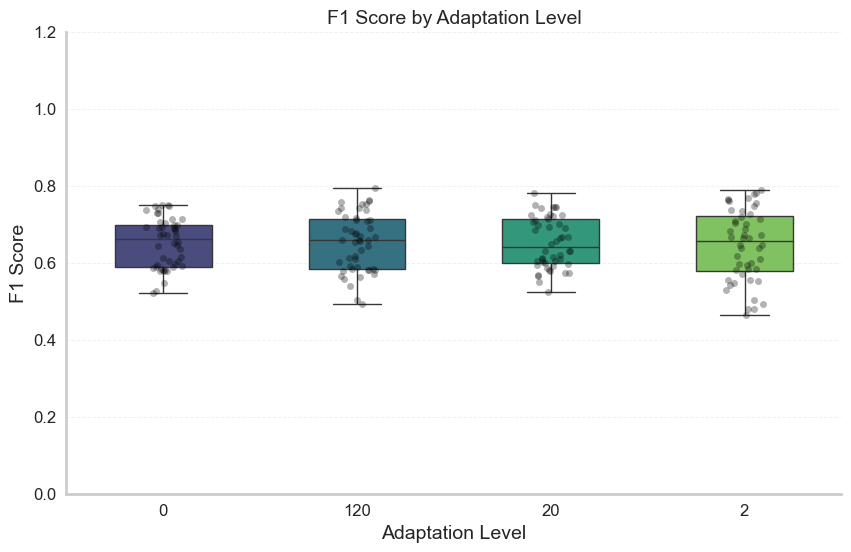

In [26]:
def plot_f1_boxplot_by_adapt(df, metric="F1", aggregate_by_network=False):
    # Define specific order
    desired_order = [0, 120, 20, 2]
    # Filter to only include values present in the dataframe
    adapt_values = [a for a in desired_order if a in df["Adapt"].unique()]
    
    # Data preparation
    if aggregate_by_network:
        # Average over sessions/channels for each network
        plot_df = df.groupby(["Network", "Adapt"])[metric].mean().reset_index()
        title_suffix = " (Averaged by Network)"
        print(f"Aggregated by network. N={len(plot_df['Network'].unique())} networks.")
    else:
        plot_df = df
        title_suffix = ""

    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Boxplot
    sns.boxplot(x="Adapt", y=metric, data=plot_df, ax=ax, palette="viridis", width=0.5, showfliers=False, order=adapt_values)
    sns.stripplot(x="Adapt", y=metric, data=plot_df, ax=ax, color="black", alpha=0.3, jitter=True, order=adapt_values)
    
    # Statistical annotation (Wilcoxon)
    if aggregate_by_network:
        pivot_cols = ["Network"]
    else:
        pivot_cols = ["Session", "Channel", "Network"]
        
    pivot = plot_df.pivot_table(index=pivot_cols, columns="Adapt", values=metric)
    pivot = pivot.dropna()
    print(f"N={len(pivot)} matched samples for statistics.")
    
    if len(pivot) > 0:
        centers = range(len(adapt_values))
        # Calculate max height for annotations
        max_val = plot_df[metric].max()
        
        combinations = list(itertools.combinations(range(len(adapt_values)), 2))
        for idx, (i, j) in enumerate(combinations):
            a1 = adapt_values[i]
            a2 = adapt_values[j]
            
            v1 = pivot[a1].values
            v2 = pivot[a2].values
            
            # Check if we have enough samples for Wilcoxon
            if len(v1) >= 3:
                stat, p = wilcoxon(v1, v2)
                
                # Stacking logic for brackets
                h = max_val + 0.05 * (1 + idx) * (max_val * 0.1)
                
                if p < 0.05:
                    print(f"{a1} vs {a2}: p={p:.4f}")
                    barplot_annotate_brackets(i, j, p, centers, [h]*len(centers), ax)
            else:
                print(f"Skipping stats for {a1} vs {a2}: N={len(v1)} too small")
    
    ax.grid(True, axis='y', linestyle='--',linewidth=0.7,alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)           
    ax.set_title(f"{metric} Score by Adaptation Level{title_suffix}",fontsize=14)
    ax.set_ylim(0, 1.2) # Adjust to fit brackets
    ax.set_ylabel(f"{metric} Score",fontsize=14)
    ax.set_xlabel("Adaptation Level",fontsize=14)
    ax.tick_params(axis='both', which='major', labelsize=12)
    ax.spines['bottom'].set_linewidth(2)
    ax.spines['left'].set_linewidth(2)
    plt.show()

if 'df' in locals():
    plot_f1_boxplot_by_adapt(df, "F1", aggregate_by_network=False)

C:\Users\NCN\AppData\Local\Temp\ipykernel_18860\1989337392.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x="Adapt", y=metric, data=plot_df, ax=ax, palette="viridis", inner="quartile", cut=0, order=adapt_values)


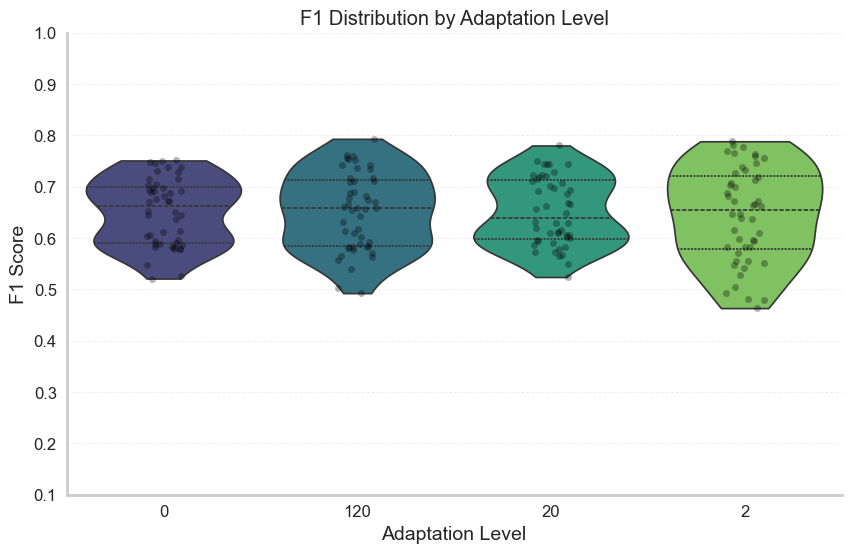

In [27]:
def plot_f1_violin_by_adapt(df, metric="F1", aggregate_by_network=False):
    # Define specific order
    desired_order = [0, 120, 20, 2]
    # Filter to only include values present in the dataframe
    adapt_values = [a for a in desired_order if a in df["Adapt"].unique()]
    
    # Data preparation
    if aggregate_by_network:
        # Average over sessions/channels for each network
        plot_df = df.groupby(["Network", "Adapt"])[metric].mean().reset_index()
        title_suffix = " (Averaged by Network)"
        print(f"Aggregated by network. N={len(plot_df['Network'].unique())} networks.")
    else:
        plot_df = df
        title_suffix = ""

    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Violin plot
    sns.violinplot(x="Adapt", y=metric, data=plot_df, ax=ax, palette="viridis", inner="quartile", cut=0, order=adapt_values)
    # Overlay points
    sns.stripplot(x="Adapt", y=metric, data=plot_df, ax=ax, color="black", alpha=0.3, jitter=True, order=adapt_values)
    
    # Statistical annotation (Wilcoxon)
    if aggregate_by_network:
        pivot_cols = ["Network"]
    else:
        pivot_cols = ["Session", "Channel", "Network"]
        
    pivot = plot_df.pivot_table(index=pivot_cols, columns="Adapt", values=metric)
    pivot = pivot.dropna()
    
    if len(pivot) > 0:
        centers = range(len(adapt_values))
        max_val = plot_df[metric].max()
        
        combinations = list(itertools.combinations(range(len(adapt_values)), 2))
        for idx, (i, j) in enumerate(combinations):
            a1 = adapt_values[i]
            a2 = adapt_values[j]
            
            v1 = pivot[a1].values
            v2 = pivot[a2].values
            
            # Check if we have enough samples for Wilcoxon
            if len(v1) >= 3: 
                stat, p = wilcoxon(v1, v2)
                
                # Stacking logic for brackets
                h = max_val + 0.05 * (1 + idx) * (max_val * 0.1)
                
                if p < 0.05:
                    print(f"{a1} vs {a2}: p={p:.4f}")
                    barplot_annotate_brackets(i, j, p, centers, [h]*len(centers), ax)
            else:
                print(f"Skipping stats for {a1} vs {a2}: N={len(v1)} too small")
                
    ax.set_title(f"{metric} Distribution by Adaptation Level{title_suffix}")
    ax.set_ylim(0.1,1) 
    ax.grid(True, axis='y', linestyle='--',linewidth=0.7,alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)           
    ax.set_ylabel(f"{metric} Score",fontsize=14)
    ax.set_xlabel("Adaptation Level",fontsize=14)
    ax.tick_params(axis='both', which='major', labelsize=12)
    ax.spines['bottom'].set_linewidth(2)
    ax.spines['left'].set_linewidth(2)
    plt.show()

if 'df' in locals():
    plot_f1_violin_by_adapt(df, "F1", aggregate_by_network=False)

C:\Users\NCN\AppData\Local\Temp\ipykernel_18860\2378848502.py:27: RuntimeWarning: divide by zero encountered in divide
  y = (f1 * x) / (2 * x - f1)


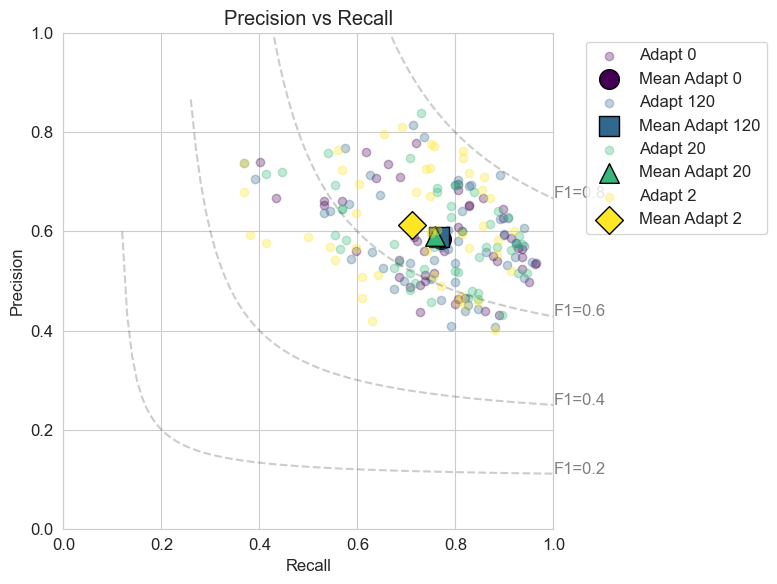

In [12]:
def plot_precision_recall(df):
    plt.figure(figsize=(8, 6))
    
     # Define specific order
    desired_order = [0, 120, 20, 2]
    # Filter to only include values present in the dataframe
    adapt_values = [a for a in desired_order if a in df["Adapt"].unique()]
    
    markers = ['o', 's', '^', 'D']
    colors = plt.cm.viridis(np.linspace(0, 1, len(adapt_values)))
    
    for i, adapt in enumerate(adapt_values):
        subset = df[df["Adapt"] == adapt]
        
        # Mean point
        mean_p = subset["Precision"].mean()
        mean_r = subset["Recall"].mean()
        
        plt.scatter(subset["Recall"], subset["Precision"], label=f"Adapt {adapt}", alpha=0.3, color=colors[i])
        plt.scatter(mean_r, mean_p, s=200, edgecolor='black', marker=markers[i%len(markers)], 
                    label=f"Mean Adapt {adapt}", color=colors[i])
        
    # F1 isolines
    f1_scores = [0.2, 0.4, 0.6, 0.8]
    x = np.linspace(0.01, 1, 100)
    for f1 in f1_scores:
        y = (f1 * x) / (2 * x - f1)
        # Filter valid y
        valid = (y >= 0) & (y <= 1)
        plt.plot(x[valid], y[valid], 'k--', alpha=0.2)
        if any(valid):
            plt.text(x[valid][-1], y[valid][-1], f"F1={f1}", color='gray')
        
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title("Precision vs Recall")
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.xlim(0, 1)
    plt.ylim(0, 1)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

if 'df' in locals():
    plot_precision_recall(df)

C:\Users\NCN\AppData\Local\Temp\ipykernel_18860\284244858.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Adapt", y="Percent Change", data=melted, palette="coolwarm", order=adapt_values)


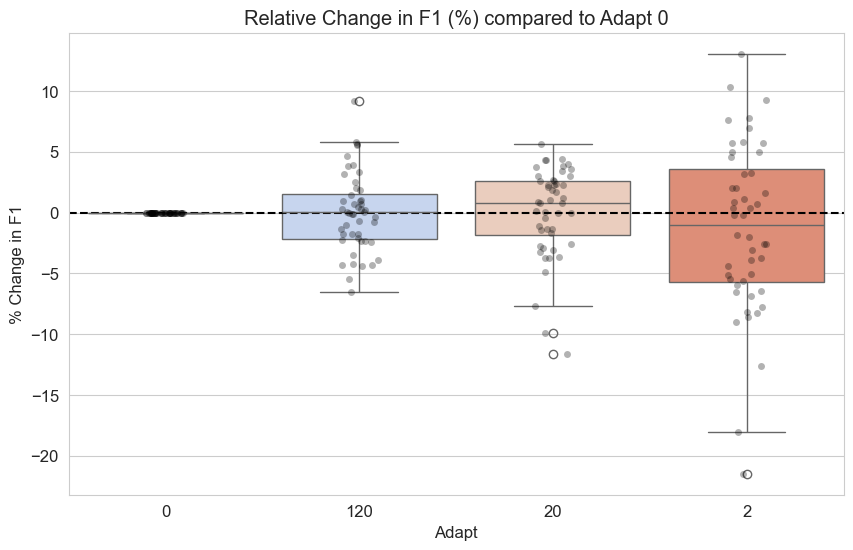

In [13]:
def plot_relative_change(df, metric="F1"):
    # Pivot to have Adapt as columns
    pivot_cols = ["Session", "Channel", "Network"]
    if "Dataset" in df.columns:
        pivot_cols.append("Dataset")
        
    pivot = df.pivot_table(index=pivot_cols, columns="Adapt", values=metric) # Pivot table
    # print(pivot.head())
    # Calculate change relative to Adapt 0 (or lowest adapt value)
     # Define specific order
    desired_order = [0, 120, 20, 2]
    # Filter to only include values present in the dataframe
    adapt_values = [a for a in desired_order if a in df["Adapt"].unique()]
    baseline_adapt = 0
    
    if baseline_adapt not in pivot.columns:
        print(f"Baseline adapt {baseline_adapt} not found in pivot columns.")
        return

    changes = pd.DataFrame()
    for col in pivot.columns:
        changes[col] = (pivot[col] - pivot[baseline_adapt]) / pivot[baseline_adapt] * 100
        
    # Melt for plotting
    melted = changes.melt(var_name="Adapt", value_name="Percent Change")
    # print(melted)
    plt.figure(figsize=(10, 6))
    sns.boxplot(x="Adapt", y="Percent Change", data=melted, palette="coolwarm", order=adapt_values)
    # Overlay points
    sns.stripplot(x="Adapt", y="Percent Change", data=melted, color="black", alpha=0.3, jitter=True, order=adapt_values)

    plt.axhline(0, color='black', linestyle='--')
    plt.title(f"Relative Change in {metric} (%) compared to Adapt {baseline_adapt}")
    plt.ylabel(f"% Change in {metric}")
    plt.show()

if 'df' in locals():
    plot_relative_change(df, "F1")